1. Initializing system...
Device: cuda
2. Loading AI Brain...
Loading weights from: c:\Users\MangOS\plant-disease-ai\models\resnet18_phase2_best.pth
3. Running Diagnostic and Grad-CAM...
Selected Image: c:\Users\MangOS\plant-disease-ai\data\PlantVillage\Blueberry___healthy\343c75ef-7bf4-4cf9-bf06-4f89c6dd94af___RS_HL 5215.JPG
Analyzing image: c:\Users\MangOS\plant-disease-ai\data\PlantVillage\Blueberry___healthy\343c75ef-7bf4-4cf9-bf06-4f89c6dd94af___RS_HL 5215.JPG
AI Prediction: Blueberry: Healthy (100.00%)


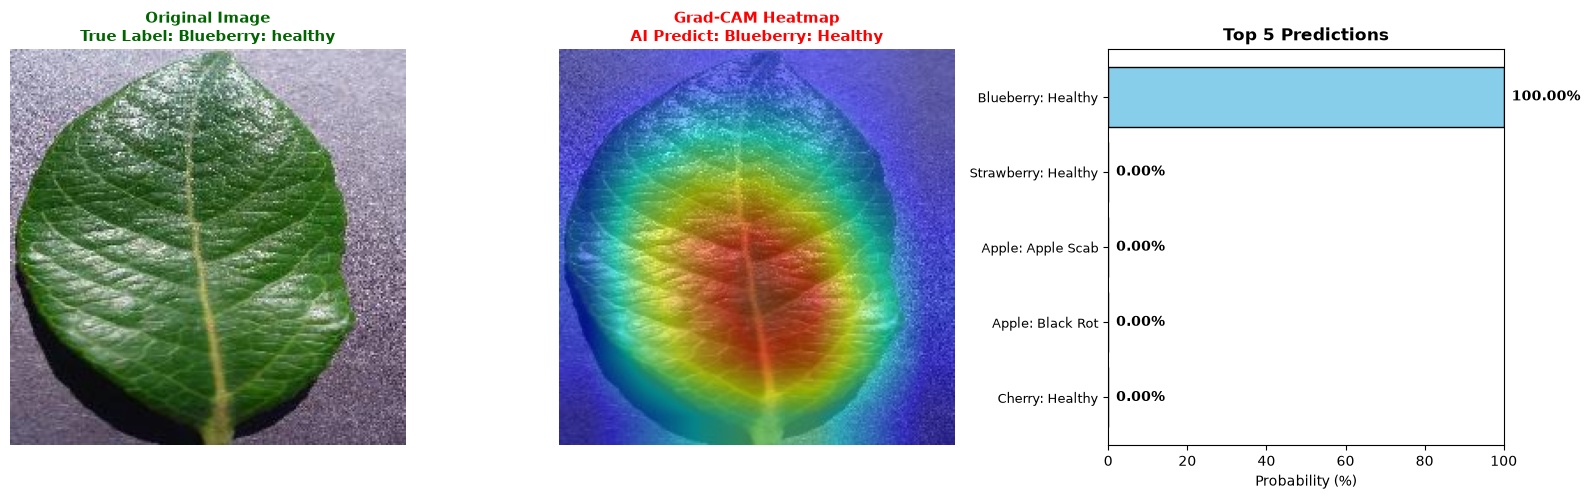

Demo completed successfully!


In [2]:
import sys
import os
import random
import glob
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

from src.load_model import load_best_model
from src.gradcam import visualize_gradcam

DATASET_DIR = os.path.join(PROJECT_ROOT, "data", "PlantVillage")  

valid_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
all_images = []

for ext in valid_extensions:
    all_images.extend(glob.glob(os.path.join(DATASET_DIR, "**", ext), recursive=True))

if not all_images:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào trong thư mục: {DATASET_DIR}.")

TEST_IMAGE_PATH = random.choice(all_images)

raw_folder_name = os.path.basename(os.path.dirname(TEST_IMAGE_PATH))
true_label = raw_folder_name.replace("___", ": ").replace("__", " ").replace("_", " ")

print("1. Initializing system...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

print("2. Loading AI Brain...")
model = load_best_model(device)

print(f"3. Running Diagnostic and Grad-CAM...")
print(f"Selected Image: {TEST_IMAGE_PATH}")

visualize_gradcam(model, TEST_IMAGE_PATH, true_label=true_label)

print("Demo completed successfully!")